# FailBench Dataset Visualization

Visualize a FailBench failure-injection dataset: RGB/depth observations, robot state, and the contact-point representation — per-failure-mode scatter + force magnitudes + front-cam overlay.

Point `DATASET_DIR` at any `datasets/<version>/<scene>/<task>/` folder produced by `scripts/generate_dataset_tasks.py`. Defaults to the preflight slice.

**npz schema** (see `planner/experiments/manager.py:save_sample_npz`):
- `pre_rgb`, `pre_depth`, `ee_cam_rgb`, `ee_cam_depth`, `post_rgb` — 480×640 camera tensors at the failure instant (post_rgb is after last-mode settle)
- `pre_qpos`, `pre_qvel`, `pre_ee_pos`, `pre_gripper_ctrl` — robot snapshot
- `traj_progress` ∈ [0,1] — where in the mission the failure was injected
- `task_id`, `traj_id`, `seed` — identity
- `failure_modes` — length-6 array of failure names forked from this pre-failure state
- `contact_positions` (N, 3), `contact_forces` (N, 6), `contact_geom_pairs` (N, 2) — flattened across all 6 forks
- `contact_failure_id` (N,) — which fork (0..5) each contact came from
- `impacted_geom_ids` — unique geom IDs touched across all forks

In [1]:
import os, sys, glob
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

DATASET_DIR = "datasets/v10_preflight/scene_level2/stack_nominal"
SCENE_XML   = "scenes/scene_level2/scene.xml"   # used by ContactProjector below

files = sorted(glob.glob(os.path.join(DATASET_DIR, "*.npz")))
print(f"{len(files)} npz files in {DATASET_DIR}")
assert files, "No npz files — check DATASET_DIR"

50 npz files in datasets/v10_preflight/scene_level2/stack_nominal


## 1. Schema at a glance

In [2]:
first = np.load(files[0], allow_pickle=True)
print(f"keys ({len(first.files)}):")
for k in sorted(first.files):
    v = first[k]
    print(f"  {k:22s} shape={str(v.shape):18s} dtype={v.dtype}")
print()
print(f"task_id={str(first['task_id'][0])}  traj_id={int(first['traj_id'][0])}  "
      f"traj_progress={float(first['traj_progress'][0]):.3f}")
print(f"failure_modes={list(first['failure_modes'])}")

keys (21):
  contact_failure_id     shape=(48299,)           dtype=int32
  contact_forces         shape=(48299, 6)         dtype=float32
  contact_geom_pairs     shape=(48299, 2)         dtype=int32
  contact_positions      shape=(48299, 3)         dtype=float32
  ee_cam_depth           shape=(480, 640)         dtype=float32
  ee_cam_rgb             shape=(480, 640, 3)      dtype=uint8
  failure_modes          shape=(6,)               dtype=<U13
  failure_probs          shape=(6,)               dtype=float32
  impacted_geom_ids      shape=(26,)              dtype=int32
  post_rgb               shape=(480, 640, 3)      dtype=uint8
  pre_depth              shape=(480, 640)         dtype=float32
  pre_ee_pos             shape=(3,)               dtype=float64
  pre_gripper_ctrl       shape=(1,)               dtype=float64
  pre_qpos               shape=(7,)               dtype=float64
  pre_qvel               shape=(7,)               dtype=float64
  pre_qvel_norm          shape=(1,)       

## 2. Aggregate distributions across all samples

`traj_progress` coverage confirms stratified sampling across mission segments; `pre_qvel_norm` shows the diversity of arm speed at failure. Per-failure-mode contact counts reveal how much each mode contributes to the data.

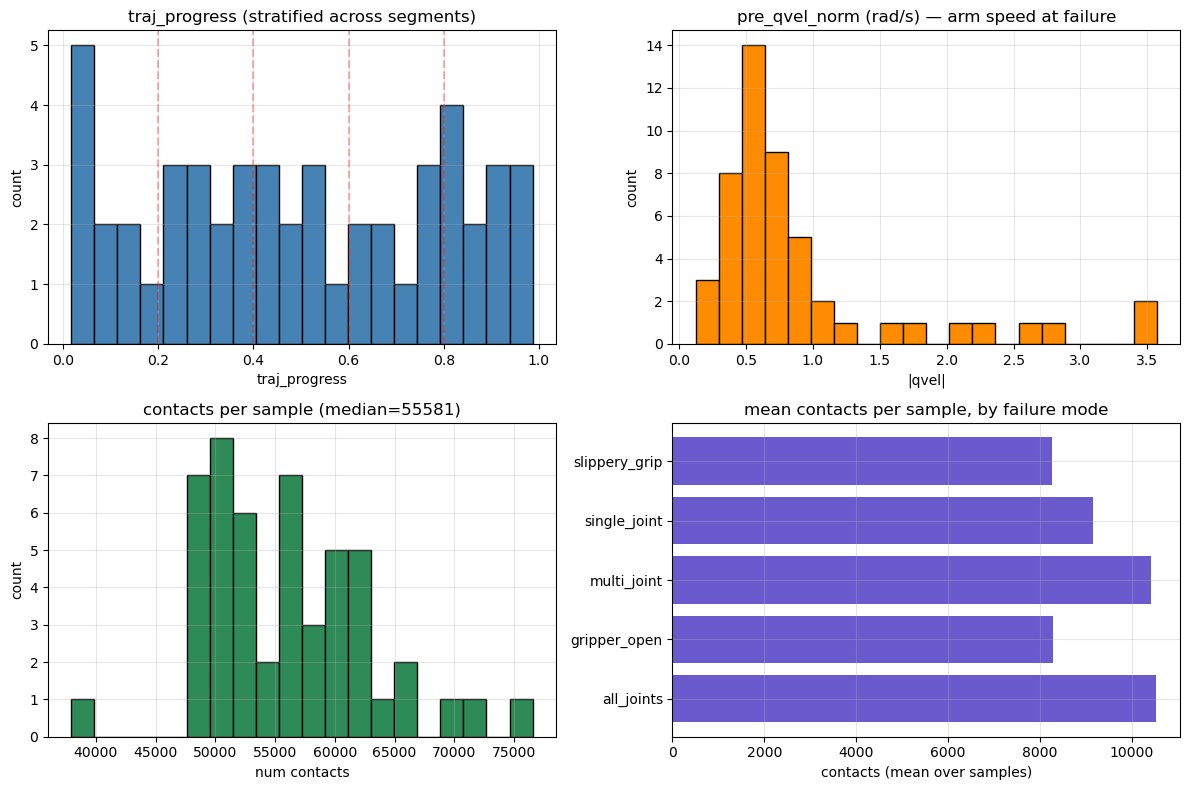

traj_progress:  [0.017, 0.987]  median=0.478
pre_qvel_norm:  [0.123, 3.572]  median=0.627


In [3]:
progs, qvels, n_contacts = [], [], []
mode_contacts = defaultdict(list)
geom_counter = Counter()

for f in files:
    d = np.load(f, allow_pickle=True)
    progs.append(float(d['traj_progress'][0]))
    qvels.append(float(d['pre_qvel_norm'][0]))
    n_contacts.append(len(d['contact_positions']))
    fids = d['contact_failure_id']
    modes = list(d['failure_modes'])
    for mid, mode in enumerate(modes):
        mode_contacts[str(mode)].append(int((fids == mid).sum()))
    for g in d['impacted_geom_ids']:
        geom_counter[int(g)] += 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(progs, bins=20, color='steelblue', edgecolor='k')
axes[0,0].set(title='traj_progress (stratified across segments)',
              xlabel='traj_progress', ylabel='count')
for x in [0.2, 0.4, 0.6, 0.8]:
    axes[0,0].axvline(x, color='r', ls='--', alpha=0.3)

axes[0,1].hist(qvels, bins=20, color='darkorange', edgecolor='k')
axes[0,1].set(title='pre_qvel_norm (rad/s) — arm speed at failure',
              xlabel='|qvel|', ylabel='count')

axes[1,0].hist(n_contacts, bins=20, color='seagreen', edgecolor='k')
axes[1,0].set(title=f'contacts per sample (median={int(np.median(n_contacts))})',
              xlabel='num contacts', ylabel='count')

names = sorted(mode_contacts)
means = [np.mean(mode_contacts[n]) for n in names]
axes[1,1].barh(names, means, color='slateblue')
axes[1,1].set(title='mean contacts per sample, by failure mode',
              xlabel='contacts (mean over samples)')
for a in axes.flat: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'traj_progress:  [{min(progs):.3f}, {max(progs):.3f}]  median={np.median(progs):.3f}')
print(f'pre_qvel_norm:  [{min(qvels):.3f}, {max(qvels):.3f}]  median={np.median(qvels):.3f}')

## 3. Impacted geom frequency

Which geoms get hit across samples. High-frequency geoms (floor=0, fingertips) are contact by construction — the task-relevant signal is in medium-frequency obstacle geoms.

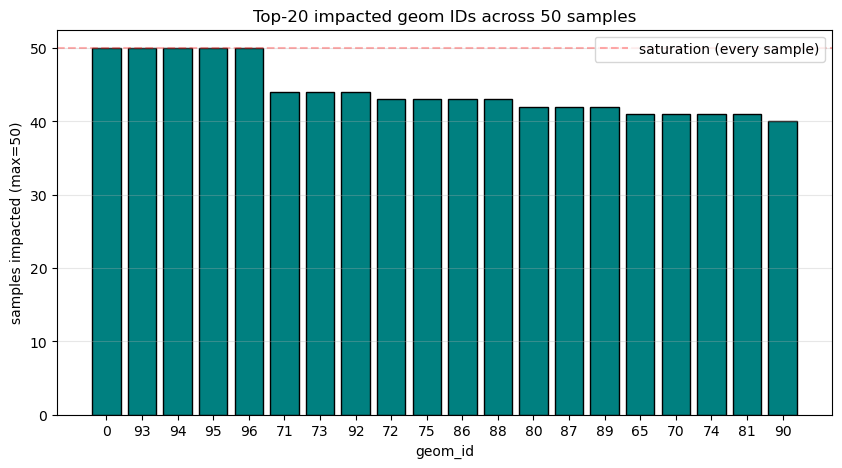

In [4]:
top = geom_counter.most_common(20)
ids, cnts = zip(*top)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([str(i) for i in ids], cnts, color='teal', edgecolor='k')
ax.set(title=f'Top-20 impacted geom IDs across {len(files)} samples',
       xlabel='geom_id', ylabel='samples impacted (max={})'.format(len(files)))
ax.axhline(len(files), color='r', ls='--', alpha=0.3, label='saturation (every sample)')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.show()

## 4. One sample in detail — cameras

Pick an interesting sample (mid-mission = during transport, when the grasped object is airborne and failure yields the most complex outcome).

Sample: exp_000017.npz
  task=stack_nominal  traj=3  progress=0.492  qvel_norm=0.733
  total contacts=58283, modes=[np.str_('gripper_open'), np.str_('slippery_grip'), np.str_('single_joint'), np.str_('single_joint'), np.str_('multi_joint'), np.str_('all_joints')]


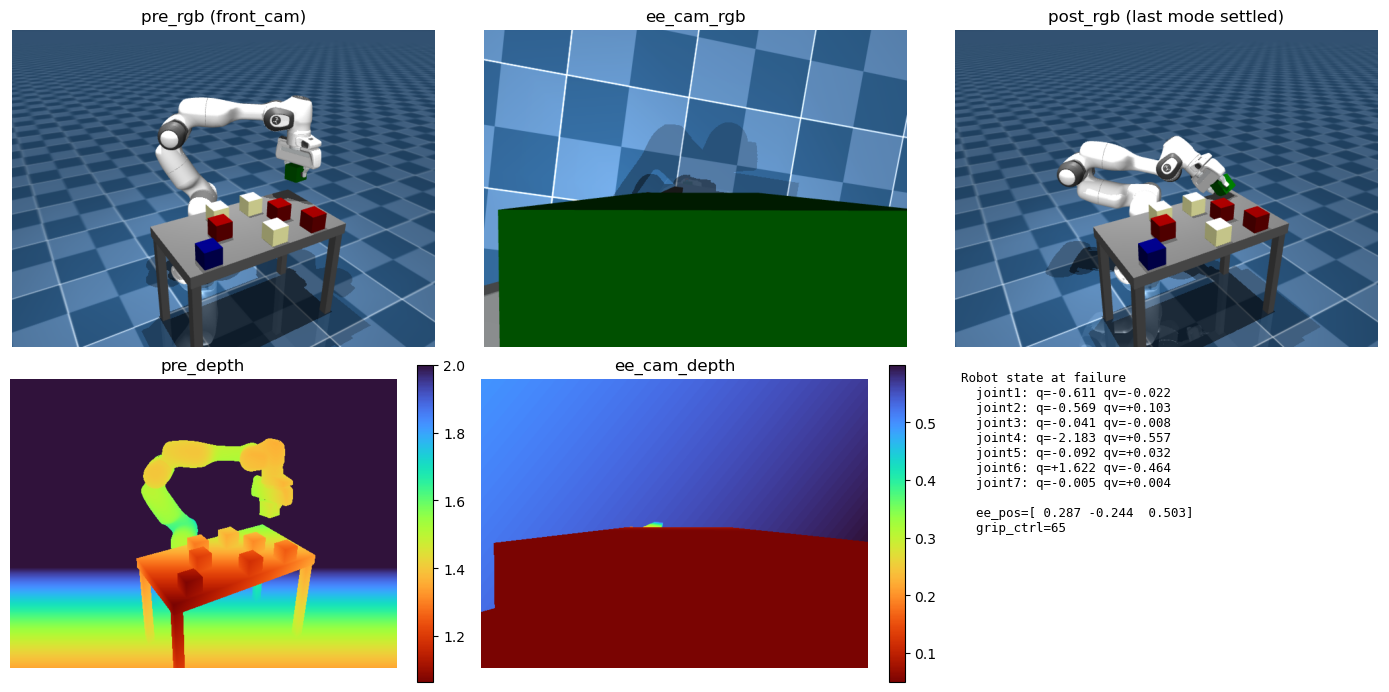

In [5]:
# Pick the sample nearest traj_progress=0.5 (mid-mission)
SAMPLE_IDX = int(np.argmin(np.abs(np.array(progs) - 0.5)))
sample_path = files[SAMPLE_IDX]
d = np.load(sample_path, allow_pickle=True)
print(f'Sample: {os.path.basename(sample_path)}')
print(f'  task={str(d["task_id"][0])}  traj={int(d["traj_id"][0])}  '
      f'progress={float(d["traj_progress"][0]):.3f}  '
      f'qvel_norm={float(d["pre_qvel_norm"][0]):.3f}')
print(f'  total contacts={len(d["contact_positions"])}, modes={list(d["failure_modes"])}')

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes[0,0].imshow(d['pre_rgb']); axes[0,0].set_title('pre_rgb (front_cam)')
axes[0,1].imshow(d['ee_cam_rgb']); axes[0,1].set_title('ee_cam_rgb')
axes[0,2].imshow(d['post_rgb']); axes[0,2].set_title('post_rgb (last mode settled)')

near, far = 0.05, 2.0
pd_clip = np.clip(d['pre_depth'], near, far)
ed_clip = np.clip(d['ee_cam_depth'], near, far)
im1 = axes[1,0].imshow(pd_clip, cmap='turbo_r'); axes[1,0].set_title('pre_depth')
plt.colorbar(im1, ax=axes[1,0], fraction=0.046)
im2 = axes[1,1].imshow(ed_clip, cmap='turbo_r'); axes[1,1].set_title('ee_cam_depth')
plt.colorbar(im2, ax=axes[1,1], fraction=0.046)

# Robot state panel
axes[1,2].axis('off')
qpos = d['pre_qpos']
qvel = d['pre_qvel']
txt  = 'Robot state at failure\n' + '\n'.join(
    f'  joint{i+1}: q={qpos[i]:+.3f} qv={qvel[i]:+.3f}' for i in range(7))
txt += f'\n\n  ee_pos={np.round(d["pre_ee_pos"], 3)}'
txt += f'\n  grip_ctrl={float(d["pre_gripper_ctrl"][0]):.0f}'
axes[1,2].text(0.02, 0.98, txt, va='top', family='monospace', fontsize=9)

for a in axes[0]: a.axis('off')
axes[1,0].axis('off'); axes[1,1].axis('off')
plt.tight_layout(); plt.show()

## 5. Contact point representation

Each contact is stored as a row in three parallel arrays:

```
contact_positions[i]   -> (x, y, z) world-frame contact location
contact_forces[i]      -> (fx, fy, fz, tx, ty, tz) wrench
contact_geom_pairs[i]  -> (geom1_id, geom2_id) pair of geoms in contact
contact_failure_id[i]  -> 0..5 — which failure-mode fork produced this contact
```

`failure_modes[contact_failure_id[i]]` gives the mode name. All six modes run from the *same* pre-failure state (same `pre_*` fields) — contacts are flattened and tagged.

### 5a. 3D scatter colored by failure mode

58283 total contacts across 6 modes


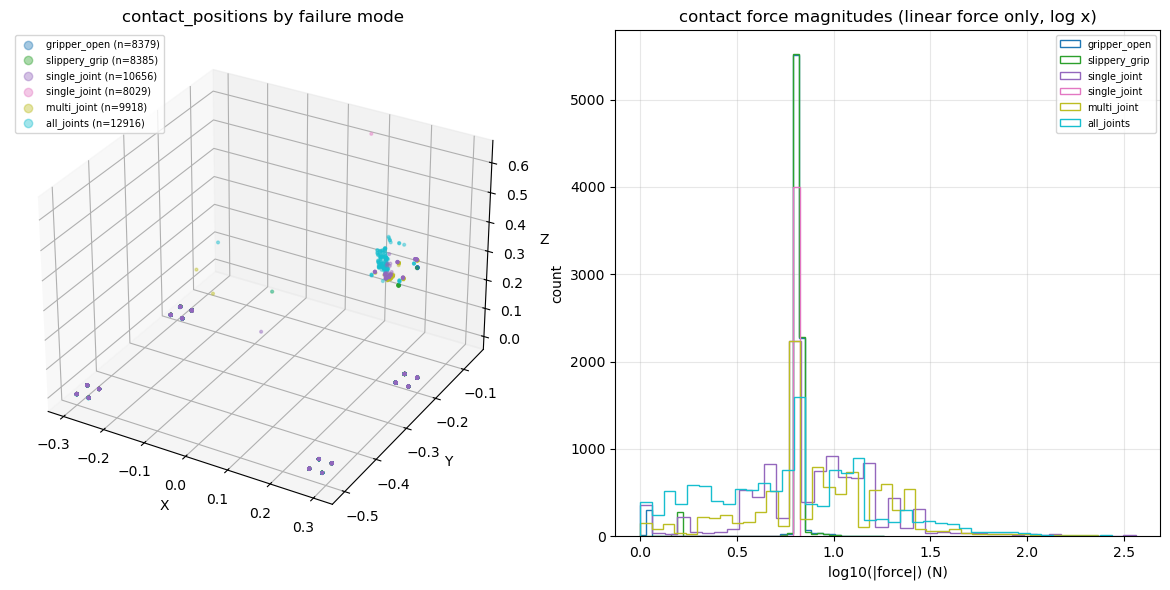

In [6]:
pos   = d['contact_positions']
forces = d['contact_forces']
pairs = d['contact_geom_pairs']
fids  = d['contact_failure_id']
modes = list(d['failure_modes'])
print(f'{len(pos)} total contacts across 6 modes')

colors = plt.cm.tab10(np.linspace(0, 1, len(modes)))
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 2, 1, projection='3d')
# Subsample each mode to at most 300 points for speed
for mid, (mode, c) in enumerate(zip(modes, colors)):
    mask = fids == mid
    p = pos[mask]
    if len(p) > 300:
        p = p[np.random.default_rng(0).choice(len(p), 300, replace=False)]
    ax.scatter(p[:,0], p[:,1], p[:,2], c=[c], s=4, alpha=0.4,
               label=f'{mode} (n={int(mask.sum())})')
ax.set(xlabel='X', ylabel='Y', zlabel='Z', title='contact_positions by failure mode')
ax.legend(loc='upper left', fontsize=7, markerscale=3)

# 5b. Force magnitude histogram
ax2 = fig.add_subplot(1, 2, 2)
for mid, (mode, c) in enumerate(zip(modes, colors)):
    mask = fids == mid
    mag = np.linalg.norm(forces[mask, :3], axis=1)
    if len(mag):
        ax2.hist(np.log10(mag + 1e-6), bins=40, histtype='step', color=c, label=mode)
ax2.set(xlabel='log10(|force|) (N)', ylabel='count',
        title='contact force magnitudes (linear force only, log x)')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5c. Project contacts onto the front_cam image

Uses `planner.experiments.data_capture.ContactProjector` (the same projector the rest of the pipeline uses — this is the reference for any 2D contact-overlay downstream). Contacts are colored by the failure mode that produced them.

47326 / 58283 contacts project inside the front_cam frame


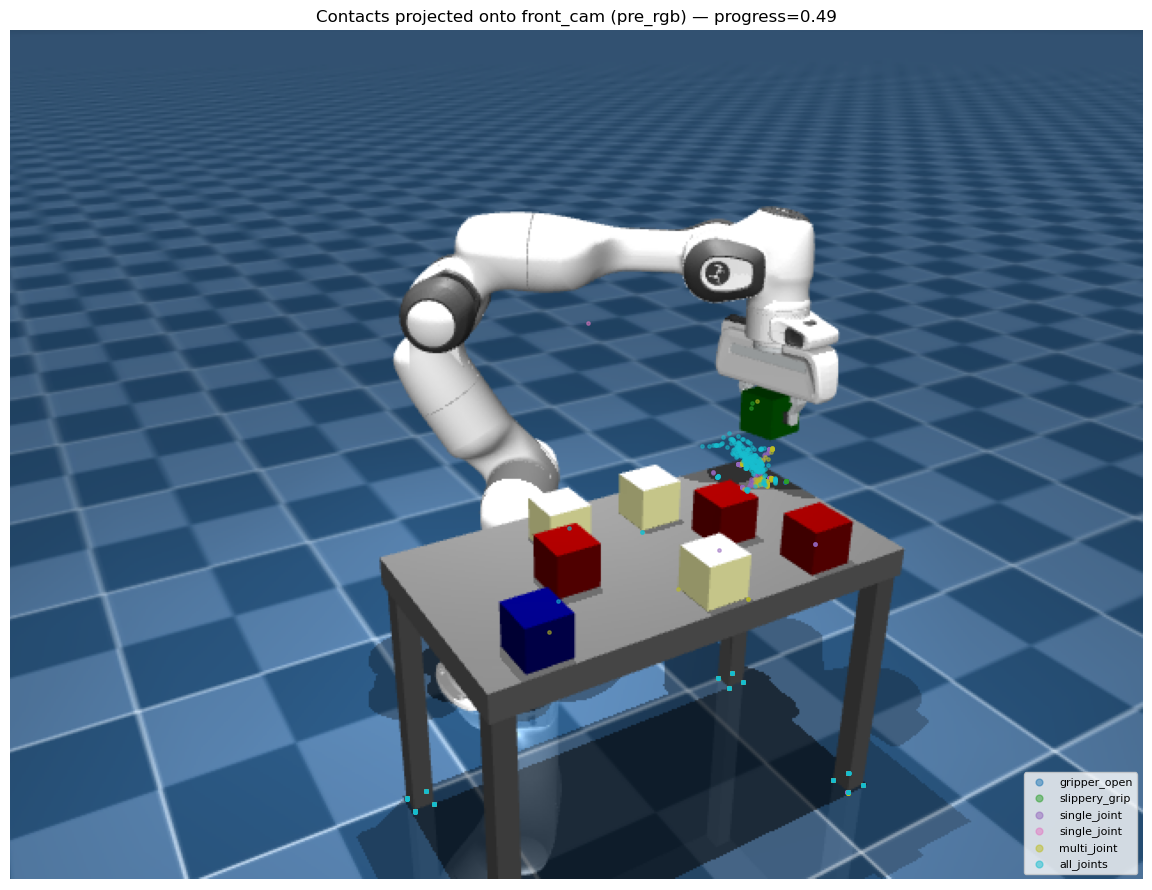

In [7]:
import mujoco
from planner.experiments.data_capture import ContactProjector

model = mujoco.MjModel.from_xml_path(SCENE_XML)
projector = ContactProjector(model, width=640, height=480, camera_name='front_cam')
pixels, depths = projector.project(pos)
# Only keep points in front of the camera and within image bounds
H, W = 480, 640
visible = (depths > 0) & (pixels[:,0] >= 0) & (pixels[:,0] < W) \
                        & (pixels[:,1] >= 0) & (pixels[:,1] < H)
print(f'{visible.sum()} / {len(pos)} contacts project inside the front_cam frame')

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
ax.imshow(d['pre_rgb'])
for mid, (mode, c) in enumerate(zip(modes, colors)):
    mask = (fids == mid) & visible
    if not mask.any(): continue
    p = pixels[mask]
    # subsample
    if len(p) > 500:
        idx = np.random.default_rng(0).choice(len(p), 500, replace=False)
        p = p[idx]
    ax.scatter(p[:,0], p[:,1], c=[c], s=6, alpha=0.5, label=f'{mode}')
ax.set(title=f'Contacts projected onto front_cam (pre_rgb) — progress={float(d["traj_progress"][0]):.2f}',
       xlim=(0, W), ylim=(H, 0))
ax.legend(fontsize=8, markerscale=2, loc='lower right')
ax.axis('off'); plt.tight_layout(); plt.show()

### 5d. Contact geom-pair frequency for this sample

Which geom pairs are in contact, per failure mode. `geom_id=0` is usually the worldbody/floor; 93–96 are gripper/fingertip geoms (contacting the held object by construction). The meaningful signal is in non-trivial pair IDs.

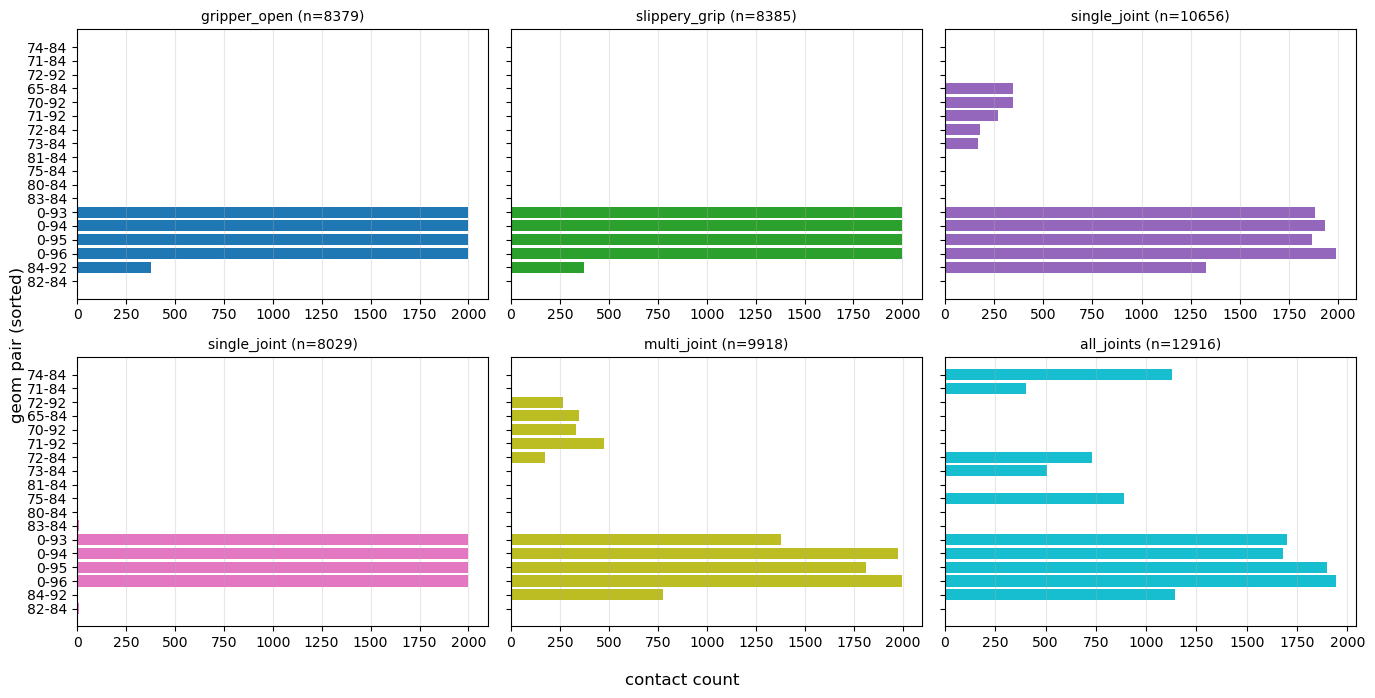

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for mid, (mode, ax) in enumerate(zip(modes, axes.flat)):
    mask = fids == mid
    if not mask.any():
        ax.set_title(f'{mode} — no contacts'); continue
    pair_keys = [tuple(sorted(p)) for p in pairs[mask]]
    cnt = Counter(pair_keys).most_common(10)
    labels = [f'{a}-{b}' for (a, b), _ in cnt]
    counts = [c for _, c in cnt]
    ax.barh(labels[::-1], counts[::-1], color=colors[mid])
    ax.set_title(f'{mode} (n={int(mask.sum())})', fontsize=10)
    ax.grid(alpha=0.3, axis='x')
fig.supxlabel('contact count'); fig.supylabel('geom pair (sorted)')
plt.tight_layout(); plt.show()

## 6. Same pre-failure state, 6 failure outcomes

Shows the key structure of the dataset: one pre-failure config → 6 parallel failure outcomes. The *pre_** fields are shared; only the contact distribution (and `post_rgb`, which captures the last fork only) differs.

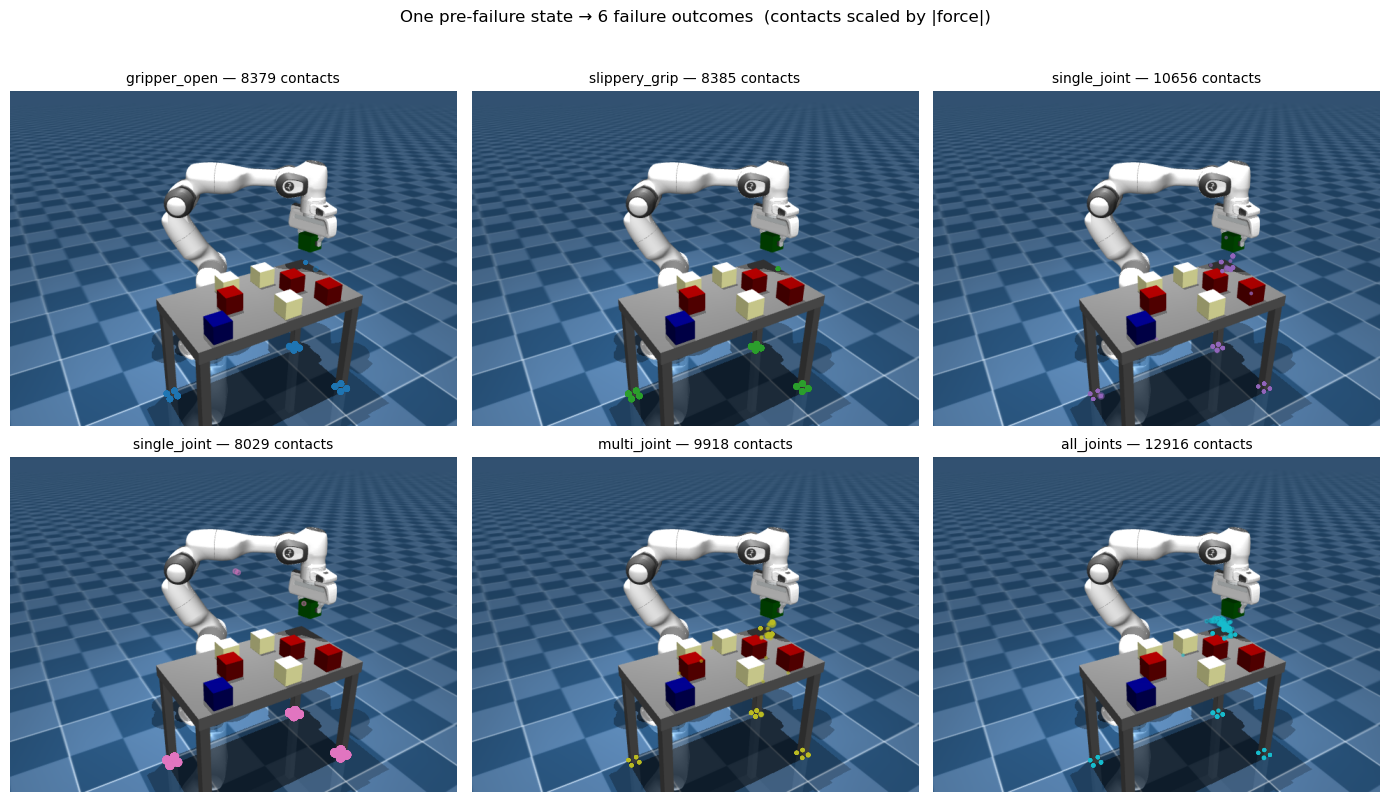

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for mid, (mode, ax) in enumerate(zip(modes, axes.flat)):
    mask = fids == mid
    mag  = np.linalg.norm(forces[mask, :3], axis=1) if mask.any() else np.array([])
    ax.imshow(d['pre_rgb'])
    if visible[mask].any():
        p = pixels[mask & visible]
        m = mag[visible[mask]] if visible[mask].shape == mag.shape else mag[:len(p)]
        sizes = 3 + 30 * (m / (m.max() + 1e-6))
        if len(p) > 300:
            idx = np.random.default_rng(0).choice(len(p), 300, replace=False)
            p, sizes = p[idx], sizes[idx]
        ax.scatter(p[:,0], p[:,1], s=sizes, c=[colors[mid]], alpha=0.4)
    ax.set_title(f'{mode} — {int(mask.sum())} contacts', fontsize=10)
    ax.axis('off')
plt.suptitle(f'One pre-failure state → 6 failure outcomes  (contacts scaled by |force|)', y=1.02)
plt.tight_layout(); plt.show()

## 7. Summary for ML modeling

**Inputs available per sample:**
- Images: `pre_rgb` (front), `ee_cam_rgb` (wrist), `pre_depth`, `ee_cam_depth`
- State: `pre_qpos` (7), `pre_qvel` (7), `pre_ee_pos` (3), `pre_gripper_ctrl`
- Context: `task_id`, `traj_progress`

**Prediction targets** (per failure mode tag from `contact_failure_id`):
- Multi-label: which `impacted_geom_ids` ∈ obstacle set (exclude floor=0 and fingertips 93–96, which are contact-by-construction)
- Per-geom impulse: integrate `contact_forces[:, :3]` norms grouped by `contact_geom_pairs`
- Coarse outcome: total `|force|` or total contact count (proxy for 'disturbance severity')

**Per-npz structure:** one pre-failure state, 6 parallel failure outcomes. Expand to 6 training examples by tagging the input with `failure_mode` as an input feature.